# CI data analysis: availability sequences based on a common carbon budget

In [1]:
# Import libraries:
from datetime import datetime
from av_mat_generation.CI_based.window import Window
MAIN_FOLDER = 'availability_matrices/av-mat-5_av-mat-analysis'

## Introduction

**Set values for countries and dates:**

In [2]:
# Number of FL training rounds:
n_rounds = 100

# Common carbon budget
global_carbon_budget = 7 # kgCO2e

main_folder = 'availability_matrices/av-mat-2/opt-pb-3-alphaFair-FT'

start_time=datetime(2022, 1, 1, 0, 0)

# list of countries/clients:
countries = ['Ireland', 'Germany', 'Great Britain', 'France', 'Sweden', 'Finland', 'Belgium']

**Definition of variables and useful functions:**

In [3]:
win = Window(start_time=start_time, n_rounds=n_rounds, 
             countries=countries, out_folder=main_folder)

**Raw CI data:**

Let us display the raw data in between the chosen dates.

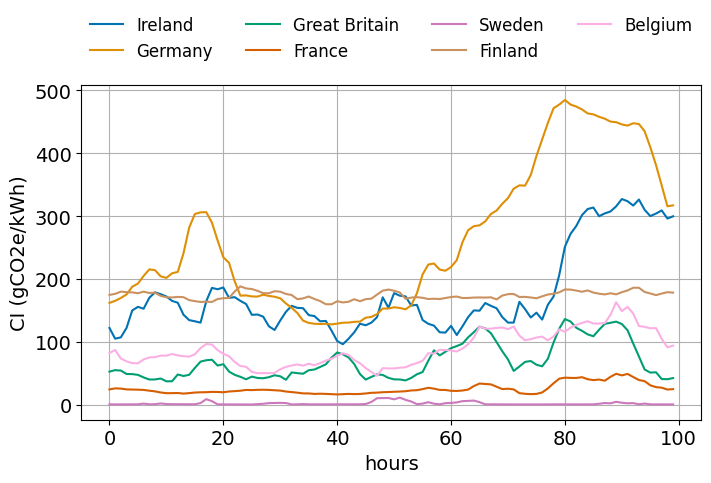

In [4]:
win.plot_raw_CI()

Lets compute the mean value for each country in between these two dates, and the global mean over all countries.

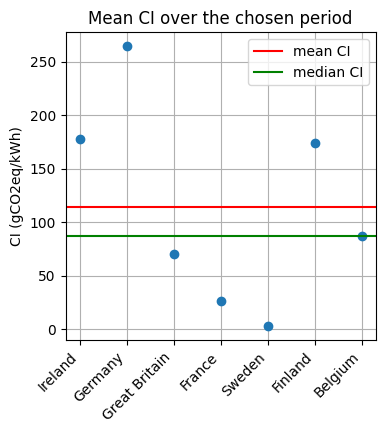

In [ ]:
win.plot_mean_CI()

**Carbon Intensity matrix:**

This matrix contains CI values in gCO2eq/kWh.

In [ ]:
display(win.CI_matrix)
# CI_matrix  = pd.DataFrame(index = countries, columns = formatted_array)
# for country in countries:
#     CI_values=get_CI_values(_dfs, country, start_date, end_date)
#     CI_matrix.loc[country, :] = CI_values

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Ireland,122.74,105.68,107.77,122.76,150.53,156.22,153.28,170.64,179.25,176.39,...,327.5,324.08,317.13,326.73,310.38,300.45,304.45,309.43,296.55,300.1
Germany,162.59,165.78,170.37,175.93,188.22,193.12,205.38,215.76,214.56,204.69,...,446.07,444.16,447.9,446.68,435.24,409.79,381.47,348.97,316.02,317.41
Great Britain,53.31,55.68,55.02,49.6,49.39,48.2,44.13,40.78,40.9,42.37,...,128.94,119.08,97.86,77.37,56.71,51.78,52.34,41.58,41.29,43.07
France,25.09,26.73,26.4,25.11,24.88,24.65,24.25,23.06,21.99,20.19,...,47.37,49.7,44.77,40.01,38.19,31.6,28.7,27.81,24.88,25.54
Sweden,1.34,1.33,1.33,1.36,1.36,1.39,2.54,1.44,1.58,2.79,...,3.92,3.01,3.31,1.42,2.6,1.38,1.31,1.26,1.26,1.3
Finland,175.21,176.89,180.41,179.56,179.22,177.88,180.33,178.28,178.74,173.6,...,179.55,182.28,186.64,186.54,179.91,177.46,174.9,177.33,179.56,178.8
Belgium,83.93,90.28,74.5,70.81,69.22,68.82,70.8,77.33,75.32,67.86,...,150.81,157.35,146.73,127.17,126.04,122.7,123.05,106.56,93.0,96.16


**GHG matrix:** 

We suppose that the power draw for all clients is constant and equal. At the moment we take the constant **300 Watts**.

The formula for carbon footprint is: power (W) * duration (hour) * carbon intensity (gCO2/kWh) * 1000

It contains the values of carbon fooprint of sustaining a certain power during ``round_duration`` hours

In [ ]:
# power = 300/1000 # in kiloWatts
# round_duration = 1 # in hours: this is duration of a FL training round
# GHG_matrix = CI_matrix * power * round_duration / 1000
# GHG_mat_np = GHG_matrix.to_numpy()

display(win.GHG_matrix)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Ireland,0.036822,0.031704,0.032331,0.036828,0.045159,0.046866,0.045984,0.051192,0.053775,0.052917,...,0.09825,0.097224,0.095139,0.098019,0.093114,0.090135,0.091335,0.092829,0.088965,0.09003
Germany,0.048777,0.049734,0.051111,0.052779,0.056466,0.057936,0.061614,0.064728,0.064368,0.061407,...,0.133821,0.133248,0.13437,0.134004,0.130572,0.122937,0.114441,0.104691,0.094806,0.095223
Great Britain,0.015993,0.016704,0.016506,0.01488,0.014817,0.01446,0.013239,0.012234,0.01227,0.012711,...,0.038682,0.035724,0.029358,0.023211,0.017013,0.015534,0.015702,0.012474,0.012387,0.012921
France,0.007527,0.008019,0.00792,0.007533,0.007464,0.007395,0.007275,0.006918,0.006597,0.006057,...,0.014211,0.01491,0.013431,0.012003,0.011457,0.00948,0.00861,0.008343,0.007464,0.007662
Sweden,0.000402,0.000399,0.000399,0.000408,0.000408,0.000417,0.000762,0.000432,0.000474,0.000837,...,0.001176,0.000903,0.000993,0.000426,0.00078,0.000414,0.000393,0.000378,0.000378,0.00039
Finland,0.052563,0.053067,0.054123,0.053868,0.053766,0.053364,0.054099,0.053484,0.053622,0.05208,...,0.053865,0.054684,0.055992,0.055962,0.053973,0.053238,0.05247,0.053199,0.053868,0.05364
Belgium,0.025179,0.027084,0.02235,0.021243,0.020766,0.020646,0.02124,0.023199,0.022596,0.020358,...,0.045243,0.047205,0.044019,0.038151,0.037812,0.03681,0.036915,0.031968,0.0279,0.028848


## Creation of availability matrix with the third problem

**Solve first optimization problem with fairness parameter alpha=0.1:**

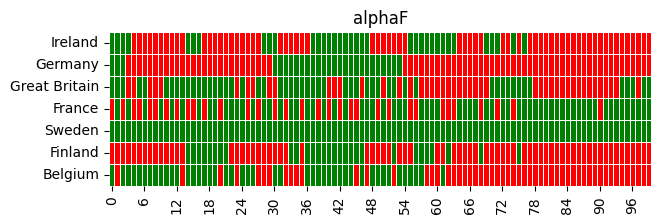

In [ ]:
av_mat = win.get_av_mat(fine_tuning=False)

**What is the end of the training?**

In [ ]:
win._find_largest_true_index(av_mat)

99

**Set the last 10 percent to available and remove green slots with the highest carbon footprint so as not to exceed the carbon budget:**

/home/chrodrig/Documents/venv_fedstale/lib64/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


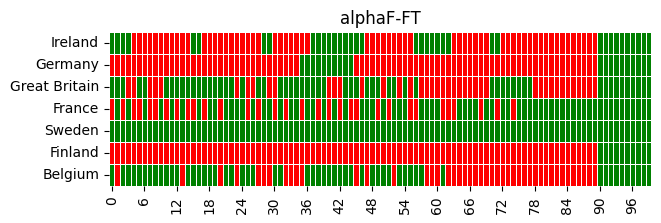

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Ireland,1,1,1,1,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
Germany,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
Great Britain,1,1,1,0,0,1,1,0,0,0,...,1,1,1,1,1,1,1,1,1,1
France,0,1,0,1,0,0,1,0,0,1,...,1,1,1,1,1,1,1,1,1,1
Sweden,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Finland,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
Belgium,1,0,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [ ]:
carbon_budget = 7

win.apply_FT(av_mat, ft=10, carbon_budget=carbon_budget)